In [26]:
import gc
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tools.simulation import DetectorSimulator
from tools.geometry import generate_detector
from tools.loader import load_event
from tools.config import create_track_hits_config
from tools.landscape import simulate_plane_arrays

print(f'JAX version: {jax.__version__}')
print(f'JAX devices: {jax.devices()}')

JAX version: 0.9.2
JAX devices: [CudaDevice(id=0)]


In [27]:
# =============================================================================
# SIMULATOR
# =============================================================================

CONFIG_PATH        = 'config/cubic_wireplane_config.yaml'
TOTAL_PAD          = 200_000
RESPONSE_CHUNK     = 50_000
MAX_ACTIVE_BUCKETS = 1000
MAX_KEYS           = 2_000_000

detector_config = generate_detector(CONFIG_PATH)
jax.clear_caches()
gc.collect()

simulator = DetectorSimulator(
    detector_config,
    use_bucketed=True,
    max_active_buckets=MAX_ACTIVE_BUCKETS,
    include_noise=False,
    include_electronics=False,
    include_track_hits=True,
    include_digitize=True,
    total_pad=TOTAL_PAD,
    response_chunk_size=RESPONSE_CHUNK,
    track_config=create_track_hits_config(max_keys=MAX_KEYS),
)
cfg = simulator.config

print('Warming up...')
simulator.warm_up()
print('Done.')

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=200,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Using BUCKETED accumulation (max_buckets=1000)
   Digitization: ENABLED (12-bit)
   Track labeling: ENABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Warming up...
Triggering JIT compilation...
JIT compilation finished (total_pad=200,000, iterate=scan).
Done.


In [28]:
# =============================================================================
# PARAMETER SWEEP CONFIG — edit here
# =============================================================================

PARAM_NAME   = 'lifetime_us'                     # SimParams field to vary
PARAM_VALUES = [5_000, 10_000, 20_000, 50_000]   # exactly four values

# Available top-level SimParams fields (all work with process_event):
#   velocity_cm_us          — drift velocity (cm/μs)
#   lifetime_us             — electron lifetime (μs)
#   diffusion_trans_cm2_us  — transverse diffusion (cm²/μs); NOTE: no effect via
#   diffusion_long_cm2_us     process_event (static kernel) — needs forward() path
# Nested recomb sub-fields require: base_params.recomb_params._replace(field=val)
#   and then: base_params._replace(recomb_params=...)

In [29]:
# =============================================================================
# DEPOSITS
# =============================================================================

DATA_PATH = 'muon.h5'
EVENT_IDX = 0

deposits = load_event(DATA_PATH, cfg, event_idx=EVENT_IDX)
n_total = sum(v.n_actual for v in deposits.volumes)
print(f'Loaded {n_total:,} deposits from event {EVENT_IDX}')

Loaded 5,335 deposits from event 0


In [30]:
from tools.landscape import response_to_arrays

def _run_with_params(simulator, deposits, sim_params, key):
    """Run process_event with given sim_params and return detector plane arrays."""
    cfg = simulator.config
    response_signals, track_hits_raw, _ = simulator.process_event(
        deposits, sim_params=sim_params, key=key
    )
    detector_arrays = response_to_arrays(response_signals, cfg)
    detector = {}
    for (vi, pi), arr in detector_arrays.items():
        name = cfg.plane_names[vi][pi]
        d = arr.T  # (num_time, num_wires)
        detector[name] = detector.get(name, 0) + d
    return detector

# =============================================================================
# RUN SWEEP — no recompilation, only physics values change
# =============================================================================

base_params = simulator.default_sim_params
sweep_results = []  # list of (param_value, detector_dict)

for val in PARAM_VALUES:
    params = base_params._replace(**{PARAM_NAME: jnp.array(float(val))})
    det = _run_with_params(simulator, deposits, params, jax.random.PRNGKey(42))
    sweep_results.append((val, det))
    print(f'{PARAM_NAME} = {val}: done')

print('Sweep complete.')

lifetime_us = 5000: done
lifetime_us = 10000: done
lifetime_us = 20000: done
lifetime_us = 50000: done
Sweep complete.


In [31]:
def sweep_wire_plane_plot(results, param_name):
    """
    Plot U, V, Y planes for each parameter value in a 3-row × N-col grid.
    Axis ranges and colour scale are consistent within each plane row.

    Parameters
    ----------
    results : list of (param_value, detector_dict)
    param_name : str
    """
    plane_names = ['U', 'V', 'Y']
    n_cols = len(results)

    def nonzero_bbox(arr):
        a = np.array(arr)
        nz = np.argwhere(a != 0)
        if len(nz) == 0:
            return None
        row_min, col_min = nz.min(axis=0)
        row_max, col_max = nz.max(axis=0)
        return int(col_min), int(col_max), int(row_min), int(row_max)

    # Compute union of nonzero bboxes and colour range per plane
    plane_ranges = {}
    plane_clim   = {}
    for pname in plane_names:
        x0, x1, y0, y1 = np.inf, -np.inf, np.inf, -np.inf
        vmin, vmax = np.inf, -np.inf
        for _, det in results:
            bbox = nonzero_bbox(det[pname])
            if bbox:
                x0 = min(x0, bbox[0]); x1 = max(x1, bbox[1])
                y0 = min(y0, bbox[2]); y1 = max(y1, bbox[3])
            a = np.array(det[pname])
            vmin = min(vmin, float(a.min()))
            vmax = max(vmax, float(a.max()))
        plane_ranges[pname] = ([int(x0), int(x1)], [int(y0), int(y1)])
        plane_clim[pname]   = (vmin, vmax)

    fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 10))
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, pname in enumerate(plane_names):
        x_range, y_range = plane_ranges[pname]
        vmin, vmax = plane_clim[pname]
        for col, (val, det) in enumerate(results):
            ax = axes[row, col]
            arr = np.array(det[pname])
            im = ax.imshow(
                arr,
                aspect='auto',
                origin='lower',
                extent=[0, arr.shape[1], 0, arr.shape[0]],
                cmap='viridis',
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xlim(x_range)
            ax.set_ylim(y_range)
            if row == 0:
                ax.set_title(f'{param_name}\n= {val}', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'{pname}  —  Wire')
            if row == len(plane_names) - 1:
                ax.set_xlabel('Time bin')
            fig.colorbar(im, ax=ax, label='Charge', fraction=0.046, pad=0.04)

    fig.suptitle(f'Wire Plane Signals — {param_name} sweep')
    fig.tight_layout()
    plt.show()

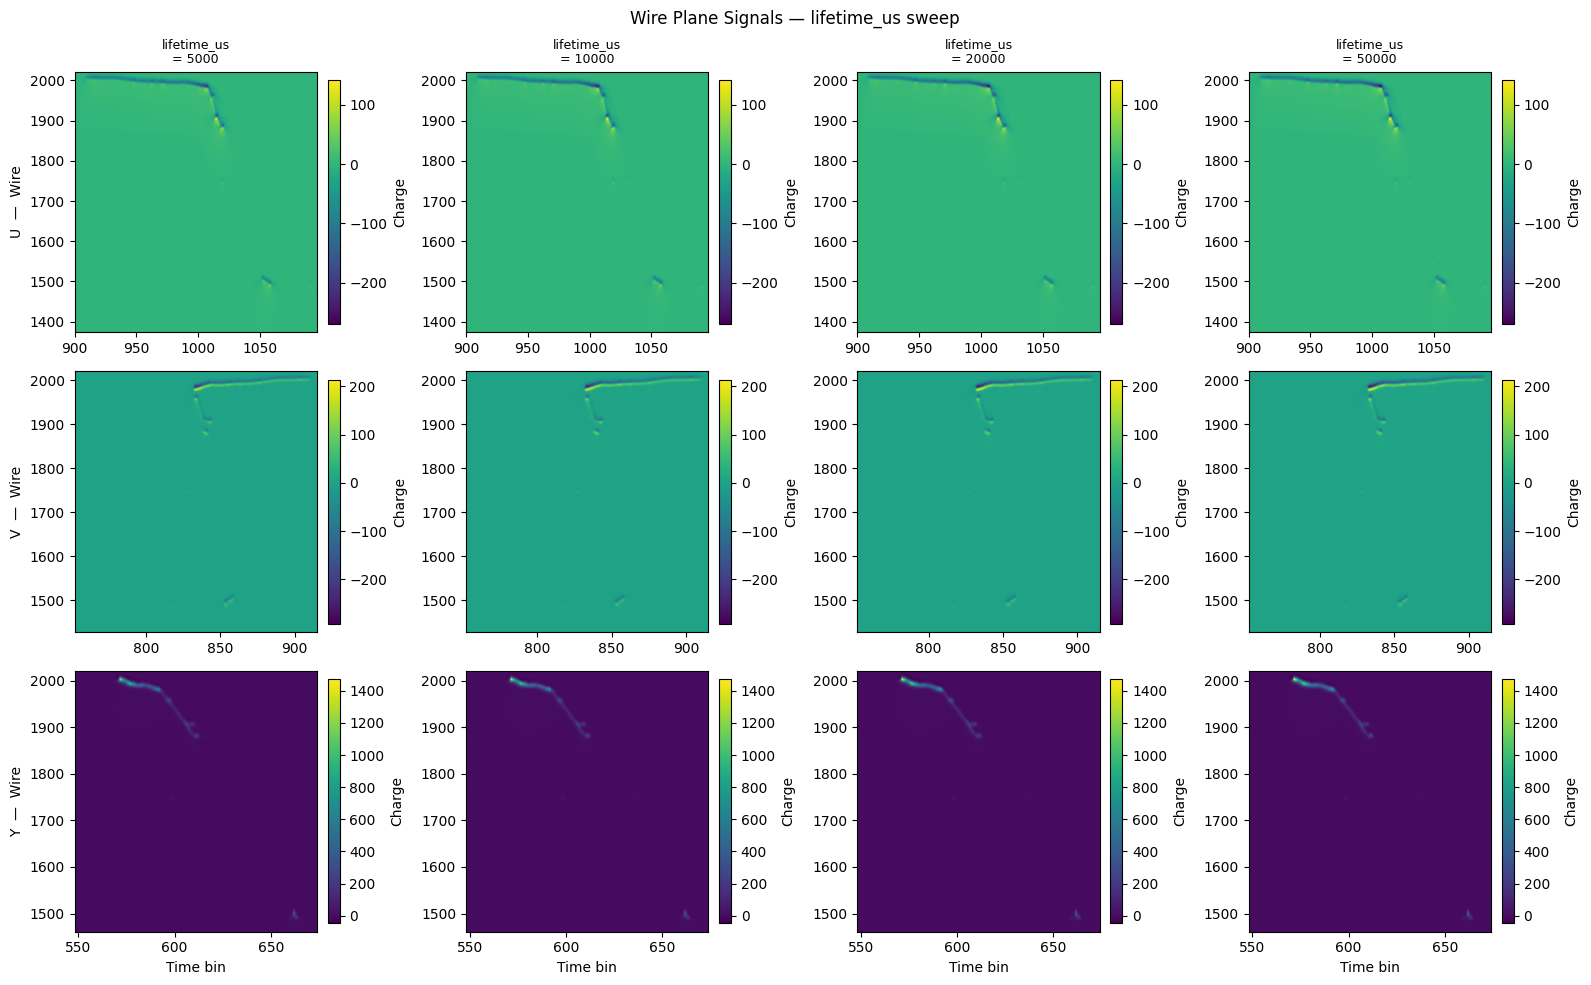

In [32]:
sweep_wire_plane_plot(sweep_results, PARAM_NAME)

In [33]:
def diff_wire_plane_plot(results, param_name):
    """
    Plot pairwise differences between consecutive parameter values.
    3 rows (U, V, Y) × (N-1) columns.  Axes consistent within each plane row.
    """
    plane_names = ['U', 'V', 'Y']

    # Build difference arrays
    diffs = []  # list of (label, diff_dict)
    for i in range(len(results) - 1):
        v0, det0 = results[i]
        v1, det1 = results[i + 1]
        label = f'{v1} − {v0}'
        diff = {p: np.array(det1[p]) - np.array(det0[p]) for p in plane_names}
        diffs.append((label, diff))

    n_cols = len(diffs)

    def nonzero_bbox(arr):
        # use the union of both signals, not just the difference
        nz = np.argwhere(arr != 0)
        if len(nz) == 0:
            return None
        row_min, col_min = nz.min(axis=0)
        row_max, col_max = nz.max(axis=0)
        return int(col_min), int(col_max), int(row_min), int(row_max)

    # Consistent axis ranges per plane — union over all difference arrays
    plane_ranges = {}
    plane_clim   = {}
    for pname in plane_names:
        x0, x1, y0, y1 = np.inf, -np.inf, np.inf, -np.inf
        absmax = 0.0
        for _, diff in diffs:
            # Bounding box from the union of both source arrays
            bbox = nonzero_bbox(diff[pname])
            if bbox:
                x0 = min(x0, bbox[0]); x1 = max(x1, bbox[1])
                y0 = min(y0, bbox[2]); y1 = max(y1, bbox[3])
            absmax = max(absmax, float(np.abs(diff[pname]).max()))
        plane_ranges[pname] = ([int(x0), int(x1)], [int(y0), int(y1)])
        plane_clim[pname]   = (-absmax, absmax)

    fig, axes = plt.subplots(3, n_cols, figsize=(4 * n_cols, 10))
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, pname in enumerate(plane_names):
        x_range, y_range = plane_ranges[pname]
        vmin, vmax = plane_clim[pname]
        for col, (label, diff) in enumerate(diffs):
            ax = axes[row, col]
            arr = diff[pname]
            im = ax.imshow(
                arr,
                aspect='auto',
                origin='lower',
                extent=[0, arr.shape[1], 0, arr.shape[0]],
                cmap='RdBu_r',
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xlim(x_range)
            ax.set_ylim(y_range)
            if row == 0:
                ax.set_title(f'{param_name}\n{label}', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'{pname}  —  Wire')
            if row == len(plane_names) - 1:
                ax.set_xlabel('Time bin')
            fig.colorbar(im, ax=ax, label='ΔCharge', fraction=0.046, pad=0.04)

    fig.suptitle(f'Pairwise differences — {param_name} sweep')
    fig.tight_layout()
    plt.show()

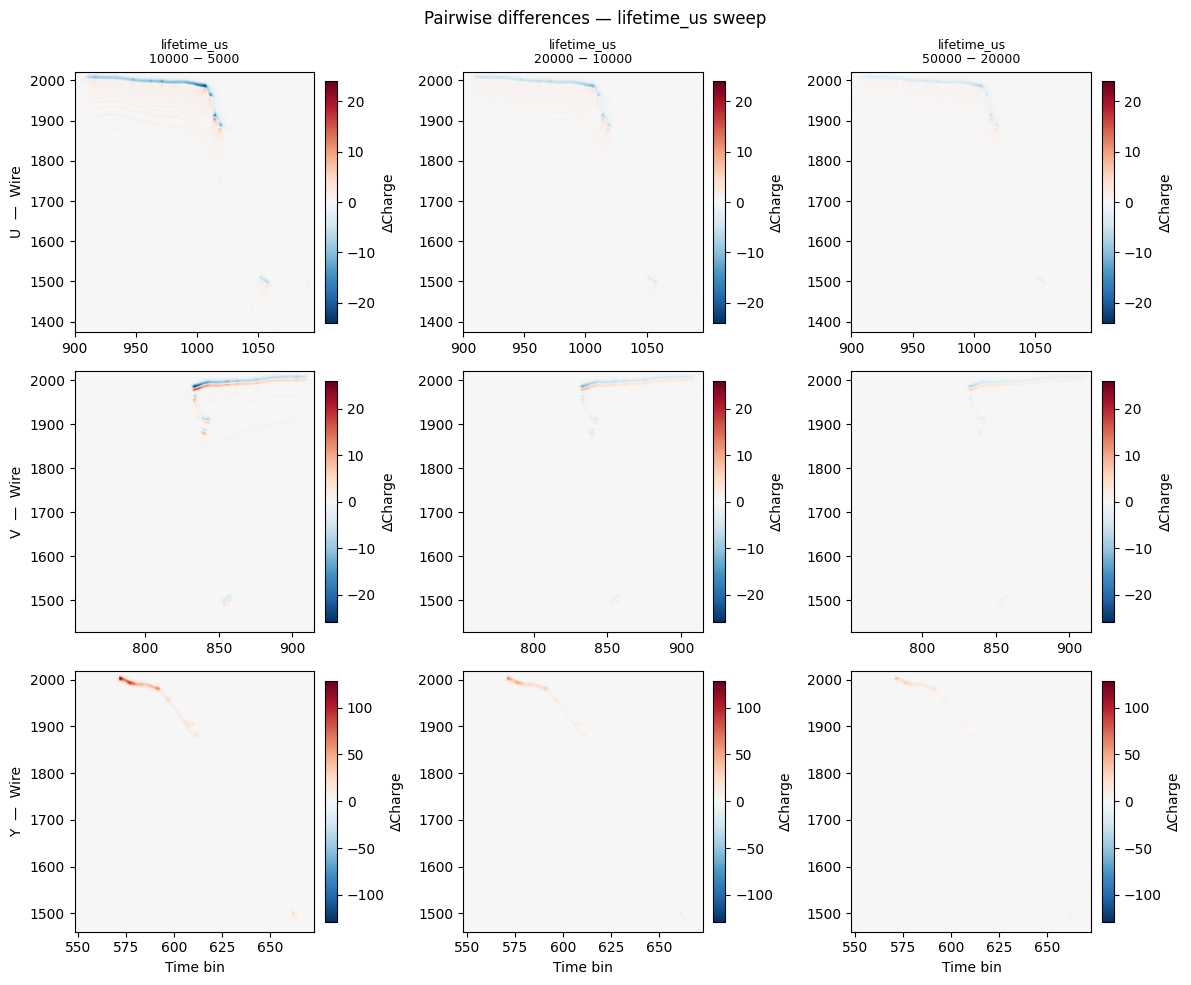

In [34]:
diff_wire_plane_plot(sweep_results, PARAM_NAME)

In [35]:
# =============================================================================
# VELOCITY SWEEP CONFIG — edit here
# =============================================================================

VEL_PARAM_NAME   = 'velocity_cm_us'
VEL_PARAM_VALUES = [0.112, 0.128, 0.144, 0.160]  # cm/μs  (70%–100% of default 0.16)

In [36]:
vel_sweep_results = []

for val in VEL_PARAM_VALUES:
    params = base_params._replace(**{VEL_PARAM_NAME: jnp.array(float(val))})
    det = _run_with_params(simulator, deposits, params, jax.random.PRNGKey(42))
    vel_sweep_results.append((val, det))
    print(f'{VEL_PARAM_NAME} = {val}: done')

print('Sweep complete.')

velocity_cm_us = 0.112: done
velocity_cm_us = 0.128: done
velocity_cm_us = 0.144: done
velocity_cm_us = 0.16: done
Sweep complete.


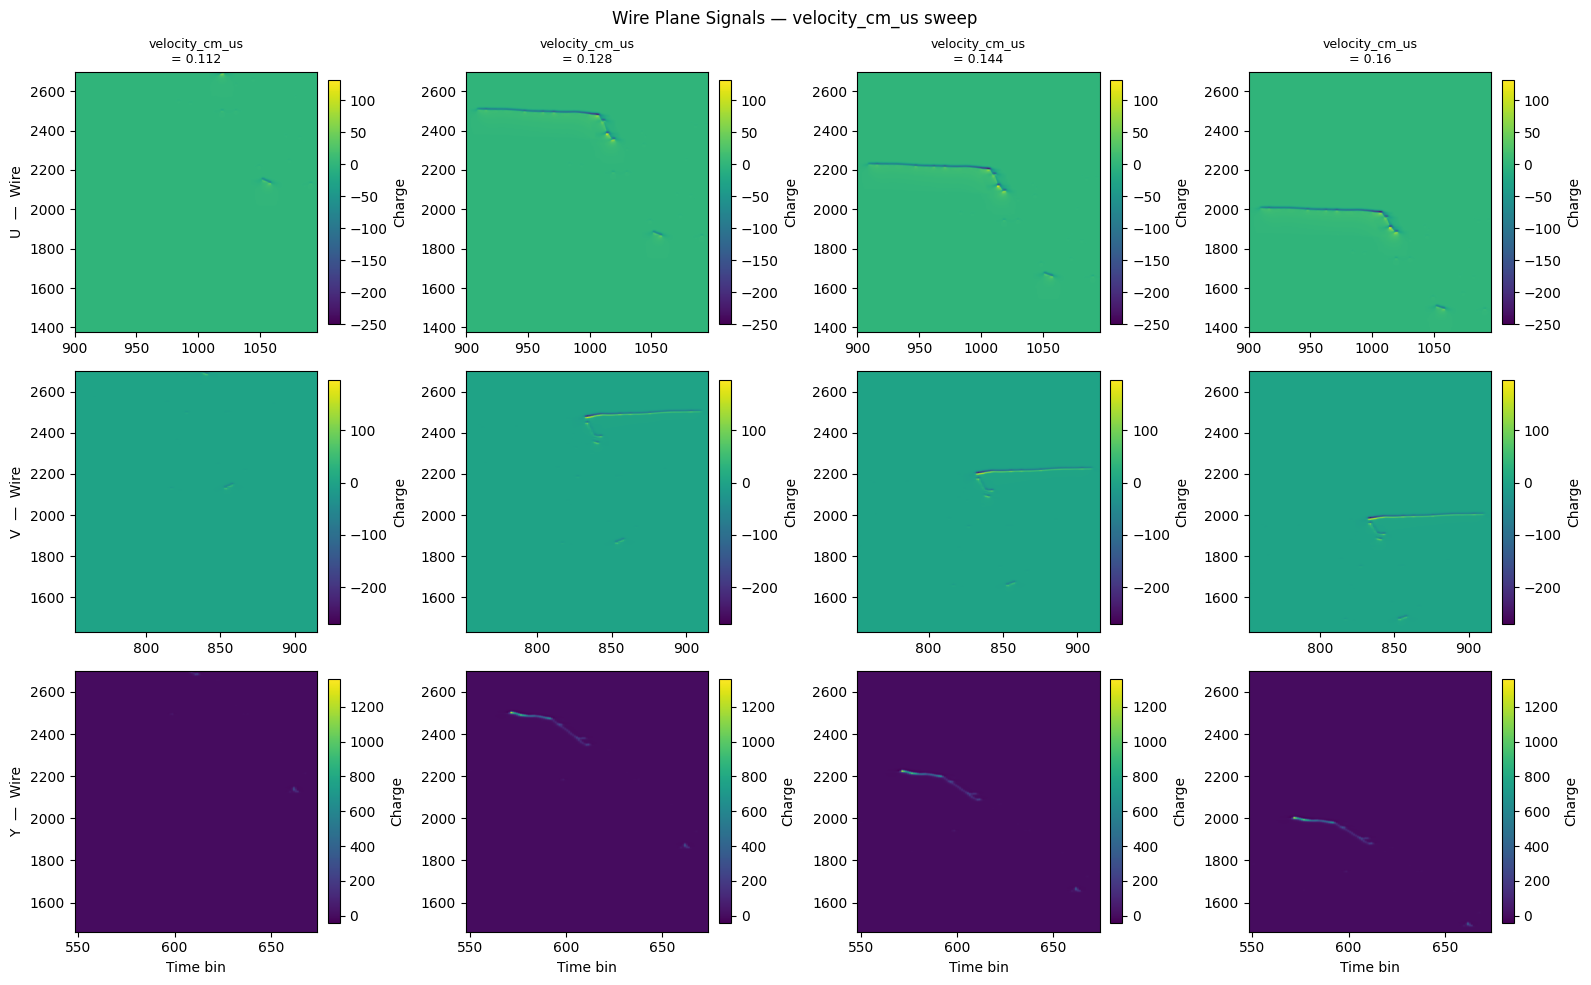

In [37]:
sweep_wire_plane_plot(vel_sweep_results, VEL_PARAM_NAME)

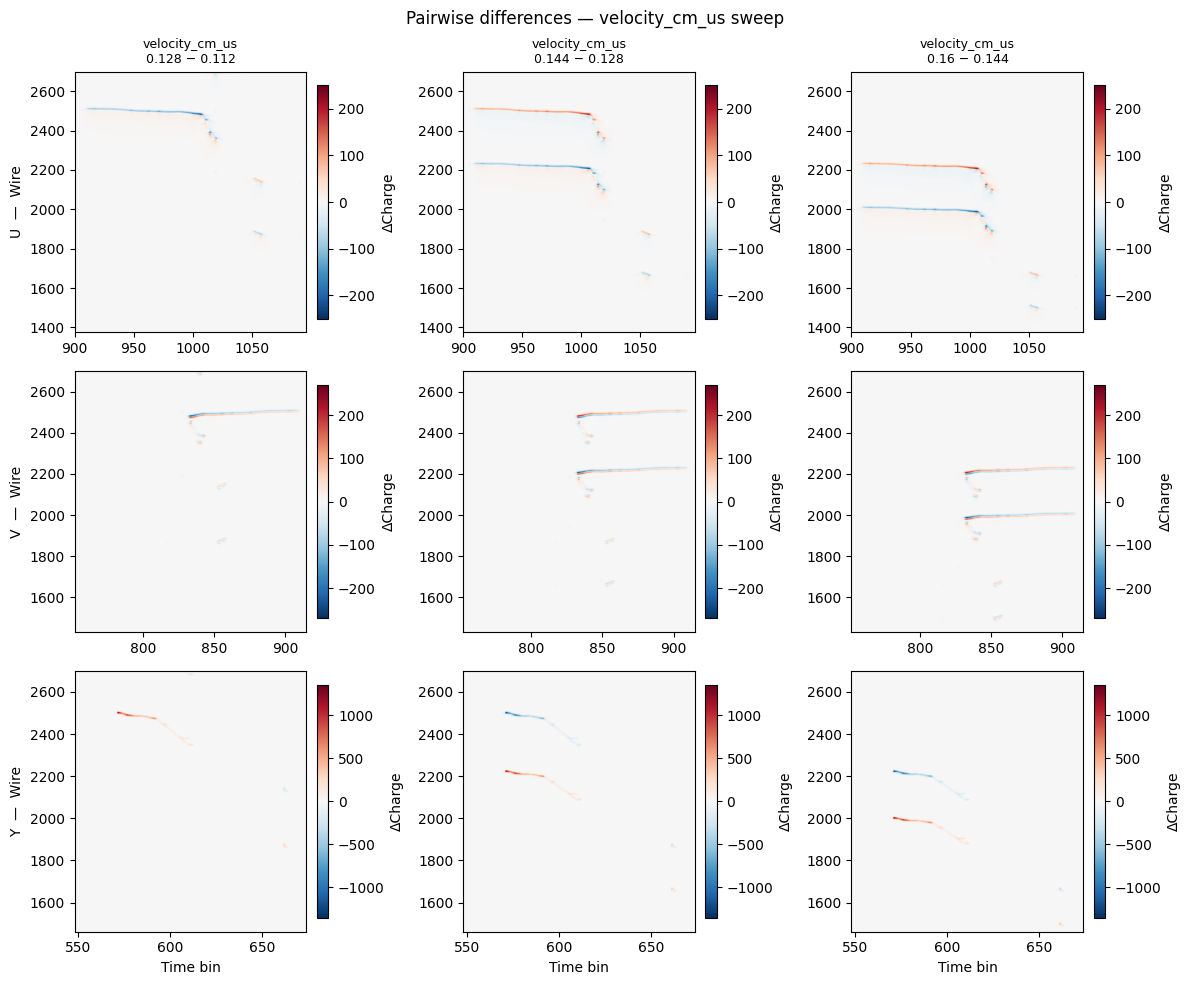

In [38]:
diff_wire_plane_plot(vel_sweep_results, VEL_PARAM_NAME)